In [15]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

In [11]:
# -----------------------------
# Configuration
# -----------------------------
CSV_FILE = "energy_with_temp.csv"  # your CSV
VALUE_COL = "P_HOME"
LAGS = [1, 2, 3, 24]  # previous hours to use as features

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv(CSV_FILE, sep=";", parse_dates=["TimeStamp"])
df = df.set_index("TimeStamp")

df = df.loc["2026-01-10":"2026-03-10"]

# Lag features
for lag in LAGS:
    df[f"lag_{lag}"] = df[VALUE_COL].shift(lag)

# Drop rows with NaNs from lag features
df = df.dropna()

# Features and target
X = df.drop(columns=[VALUE_COL])
y = df[VALUE_COL]

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

In [16]:
# -----------------------------
# Random Forest model
# -----------------------------
rf = RandomForestRegressor(random_state=42)

# Parameter grid to search
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Grid search
grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    n_jobs=-1,
    scoring="neg_mean_absolute_error",
    verbose=1
)

grid.fit(X_train, y_train)

# Best model
best_rf = grid.best_estimator_

print("Best parameters:", grid.best_params_)

Fitting 3 folds for each of 108 candidates, totalling 324 fits
Best parameters: {'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 300}


Mean Absolute Percentage Error: 46.62%


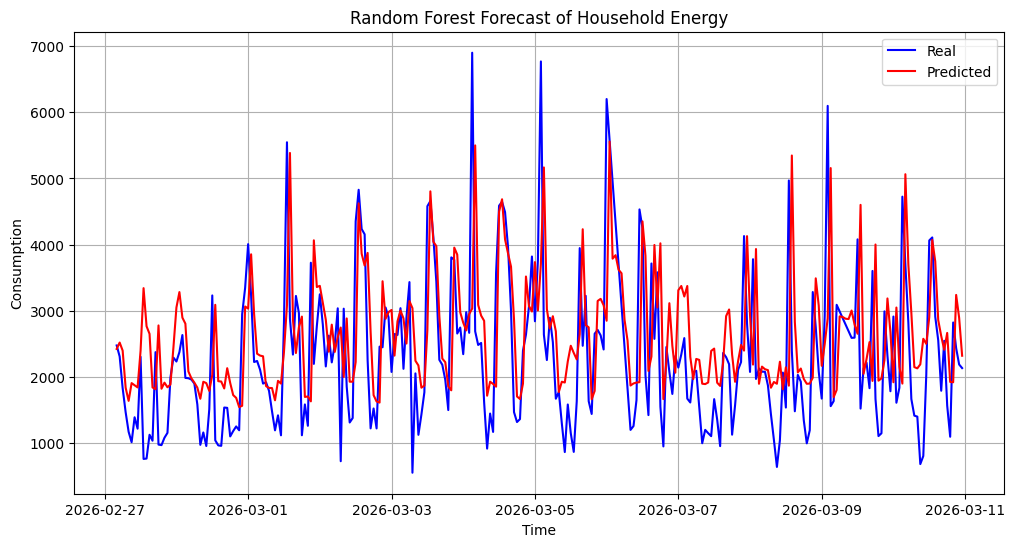

In [18]:
# Predict
y_pred = best_rf.predict(X_test)

# -----------------------------
# Evaluate
# -----------------------------
mape = mean_absolute_percentage_error(y_test, y_pred) * 100
print(f"Mean Absolute Percentage Error: {mape:.2f}%")

# -----------------------------
# Plot real vs predicted
# -----------------------------
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test.values, label="Real", color="blue")
plt.plot(y_test.index, y_pred, label="Predicted", color="red")
plt.title("Random Forest Forecast of Household Energy")
plt.xlabel("Time")
plt.ylabel("Consumption")
plt.legend()
plt.grid(True)
plt.show()